# Mutual Fund Analytics Capstone

## Exploratory Data Analysis (EDA)

Author: Sunanda Reddy

Period: 2022-2026

In [43]:
import sys
print(sys.executable)

c:\Users\Sunanda Reddy\AppData\Local\Python\pythoncore-3.14-64\python.exe


# 1. NAV Trend Analysis
Daily NAV trends across mutual fund schemes (2022–2026)


In [44]:
import nbformat
print(nbformat.__version__)

5.10.4


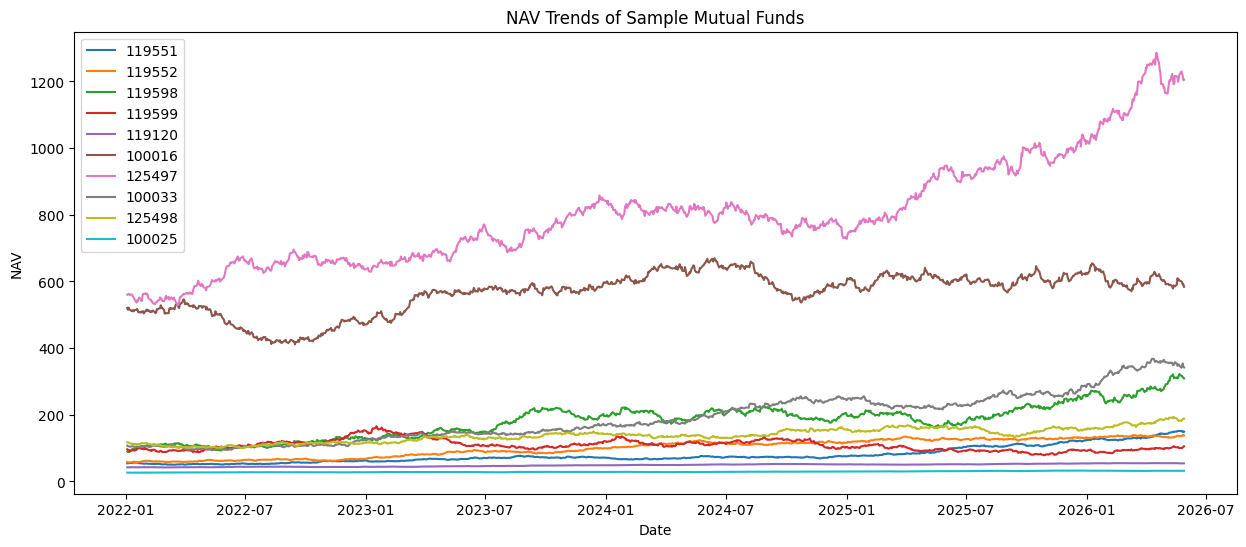

In [45]:
plt.figure(figsize=(15,6))

sample_funds = nav["amfi_code"].unique()[:10]

for fund in sample_funds:
    temp = nav[nav["amfi_code"] == fund]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(fund)
    )

plt.title("NAV Trends of Sample Mutual Funds")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.legend()

plt.savefig(
    "../reports/nav_trend.png",
    bbox_inches="tight"
)

plt.show()

In [41]:
nav["date"] = pd.to_datetime(nav["date"])

aum["date"] = pd.to_datetime(aum["date"])

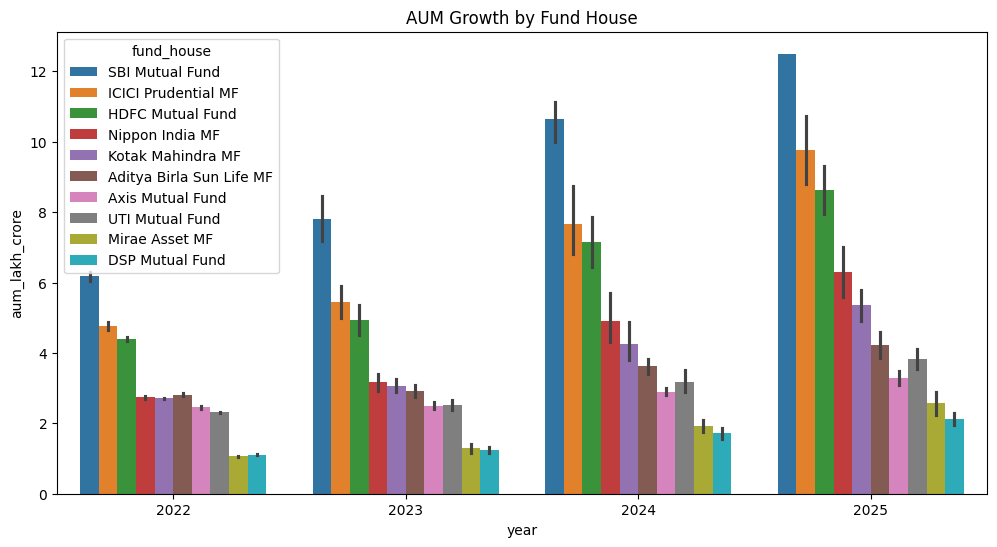

In [42]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

plt.savefig(
    "../reports/aum_growth.png",
    bbox_inches="tight"
)

plt.show()

# 3. SIP Inflow Trend Analysis
Monthly SIP inflows from 2022–2025

In [46]:
sip["month"] = pd.to_datetime(sip["month"])

print(sip.head())

       month  sip_inflow_crore  active_sip_accounts_crore  \
0 2022-01-01             11517                       4.91   
1 2022-02-01             11438                       4.93   
2 2022-03-01             12328                       5.09   
3 2022-04-01             11863                       5.48   
4 2022-05-01             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


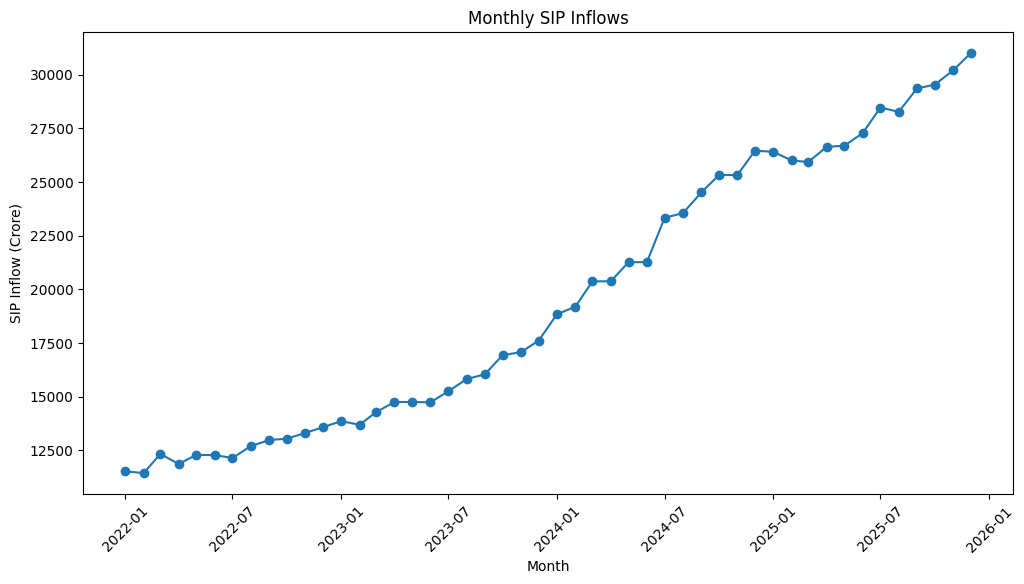

In [47]:
plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")

plt.xticks(rotation=45)

plt.savefig(
    "../reports/sip_inflow_trend.png",
    bbox_inches="tight"
)

plt.show()

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


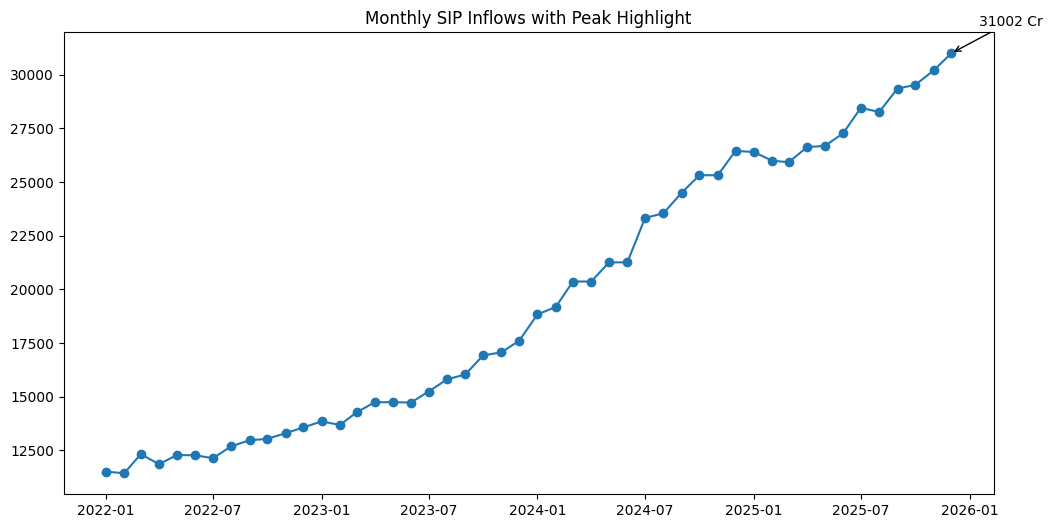

In [49]:
peak = sip.loc[sip["sip_inflow_crore"].idxmax()]

print(peak)
plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

peak = sip.loc[sip["sip_inflow_crore"].idxmax()]

plt.annotate(
    f"{peak['sip_inflow_crore']:.0f} Cr",
    xy=(peak["month"], peak["sip_inflow_crore"]),
    xytext=(20,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title("Monthly SIP Inflows with Peak Highlight")

plt.savefig(
    "../reports/sip_peak.png",
    bbox_inches="tight"
)

plt.show()

# 4. Category-wise Inflow Heatmap

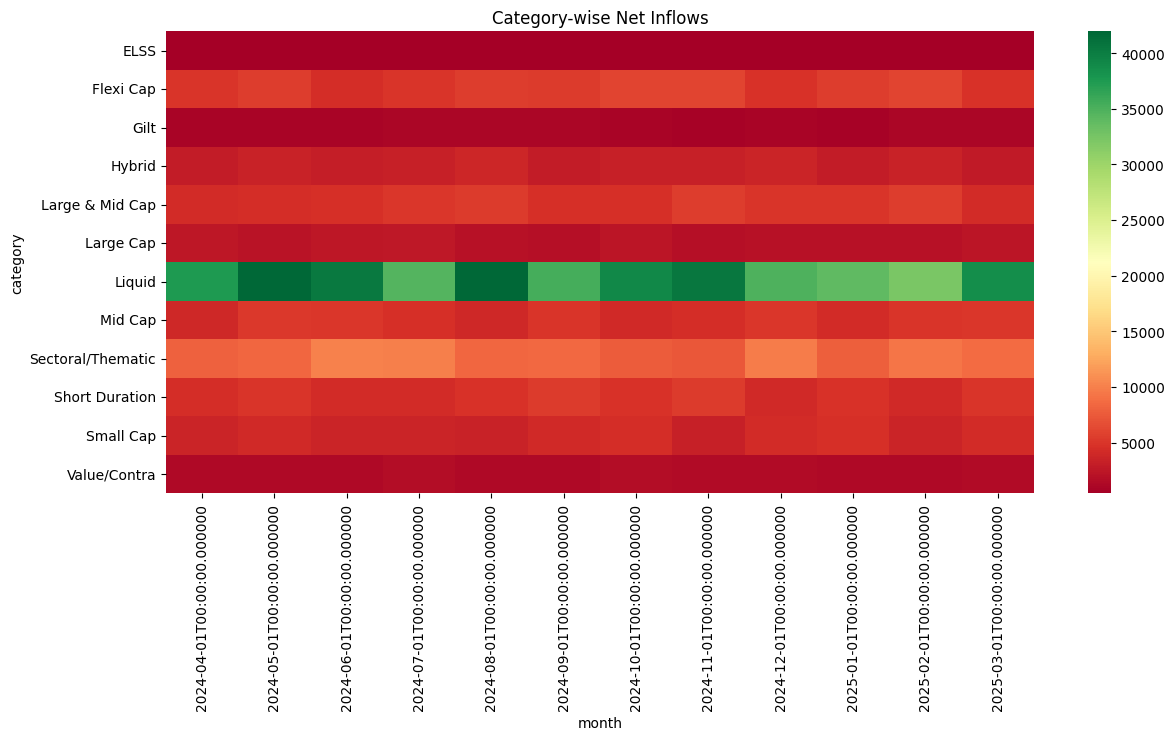

In [50]:
category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",
    annot=False
)

plt.title("Category-wise Net Inflows")

plt.savefig(
    "../reports/category_heatmap.png",
    bbox_inches="tight"
)

plt.show()

# 5. Investor Demographics Analysis

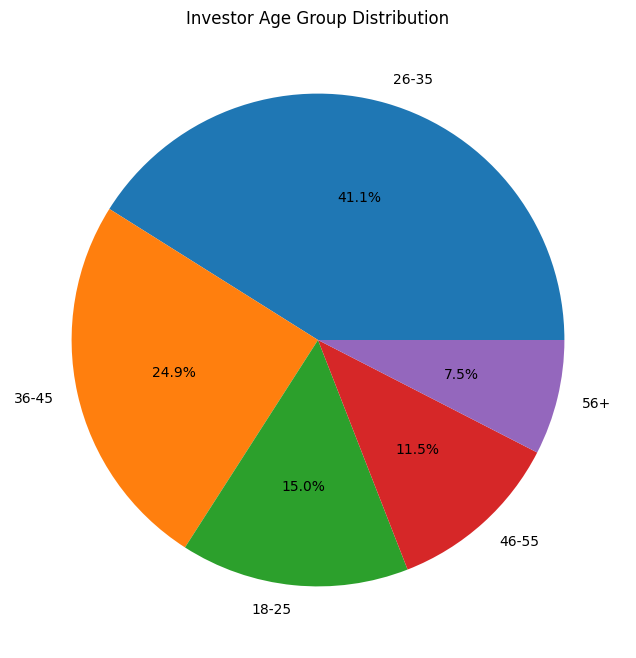

In [51]:
plt.figure(figsize=(8,8))

transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")

plt.savefig(
    "../reports/age_group_distribution.png",
    bbox_inches="tight"
)

plt.show()

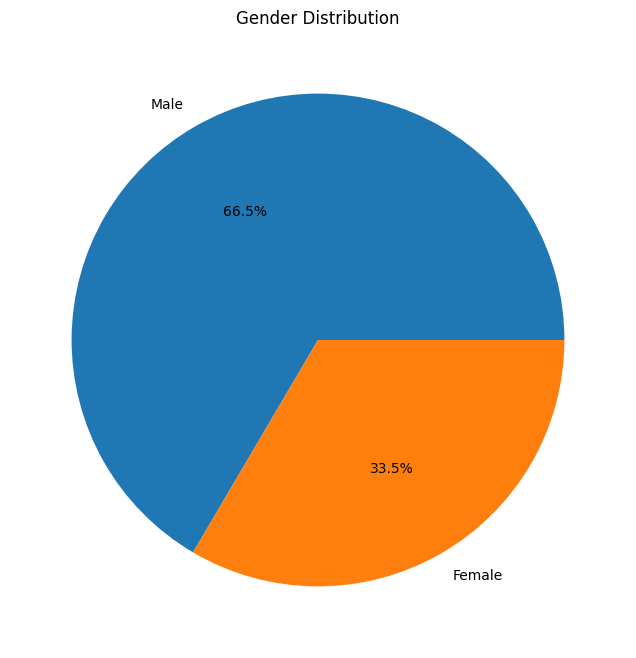

In [52]:
plt.figure(figsize=(8,8))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.ylabel("")

plt.savefig(
    "../reports/gender_distribution.png",
    bbox_inches="tight"
)

plt.show()

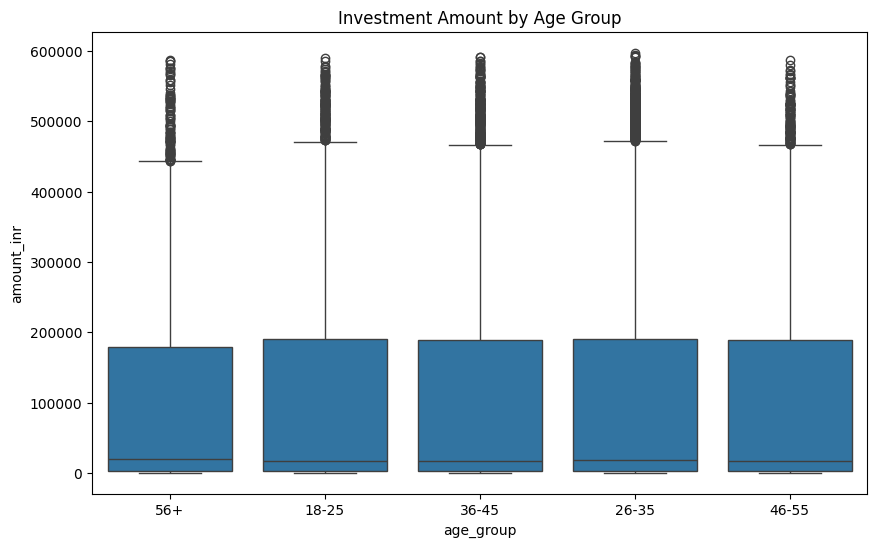

In [53]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.savefig(
    "../reports/investment_by_age.png",
    bbox_inches="tight"
)

plt.show()

# 6. Geographic Distribution Analysis

In [55]:
state_data = transactions.groupby(
    "state"
)["amount_inr"].sum().sort_values(ascending=False)

print(state_data.head())

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
Name: amount_inr, dtype: int64


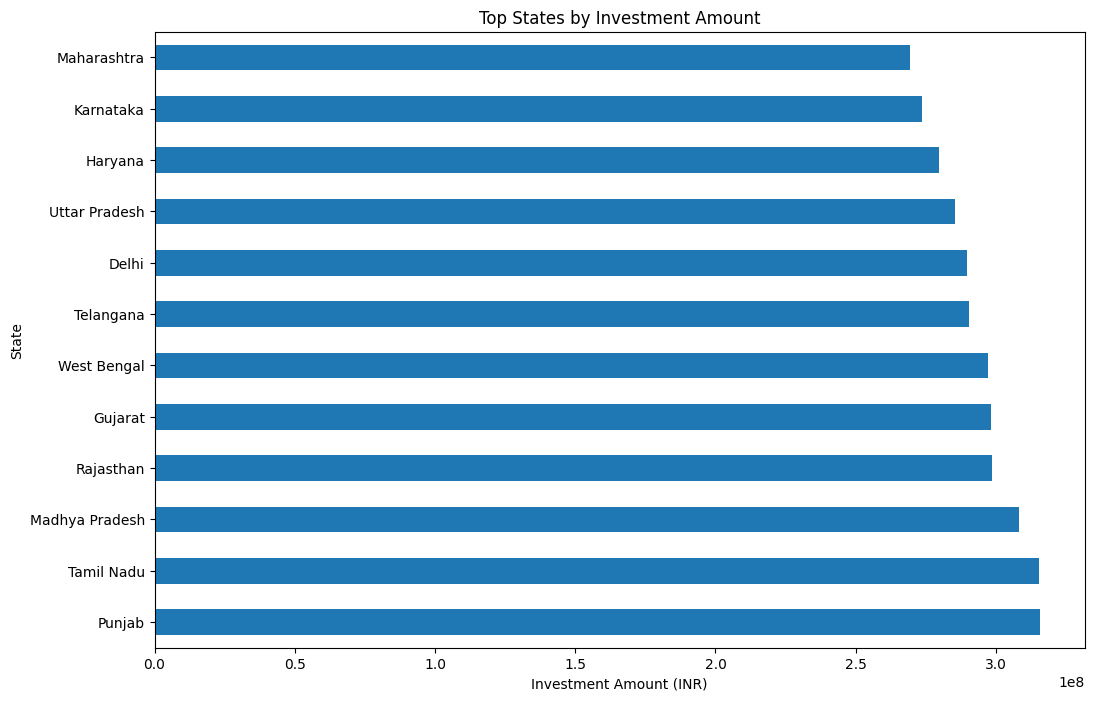

In [56]:
plt.figure(figsize=(12,8))

state_data.head(15).plot(kind="barh")

plt.title("Top States by Investment Amount")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")

plt.savefig(
    "../reports/state_investment.png",
    bbox_inches="tight"
)

plt.show()

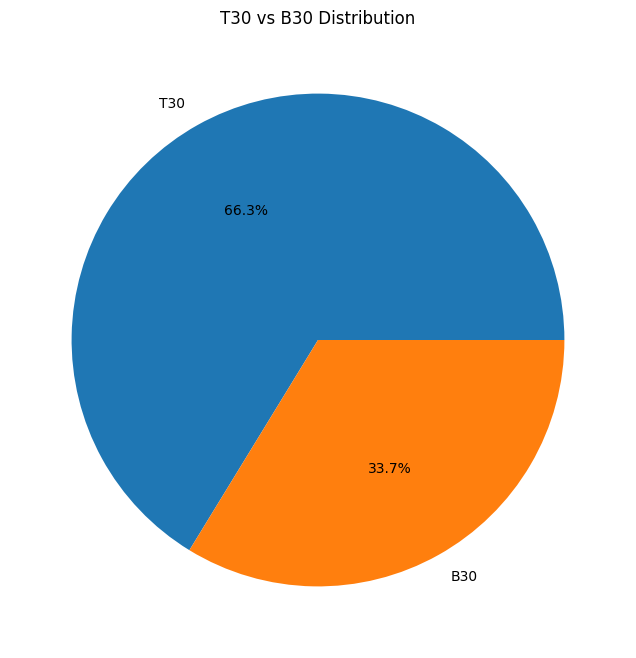

In [57]:
plt.figure(figsize=(8,8))

transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")
plt.ylabel("")

plt.savefig(
    "../reports/t30_b30_distribution.png",
    bbox_inches="tight"
)

plt.show()

# 7. Industry Folio Growth

In [58]:
folio["month"] = pd.to_datetime(folio["month"])

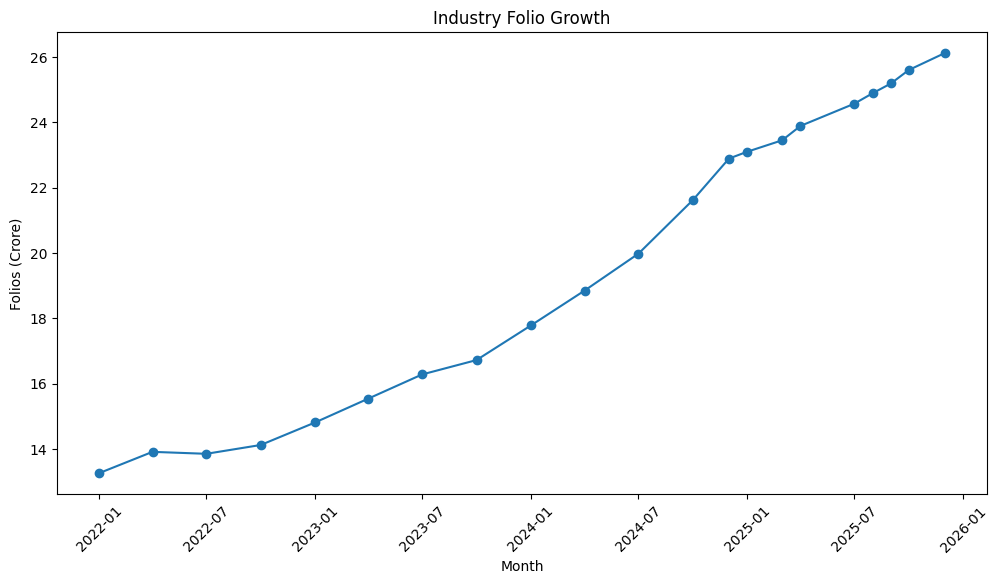

In [59]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.xticks(rotation=45)

plt.savefig(
    "../reports/folio_growth.png",
    bbox_inches="tight"
)

plt.show()

# 8. NAV Return Correlation Matrix

In [62]:
nav_wide = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)
returns = nav_wide.pct_change()
corr = returns.corr()


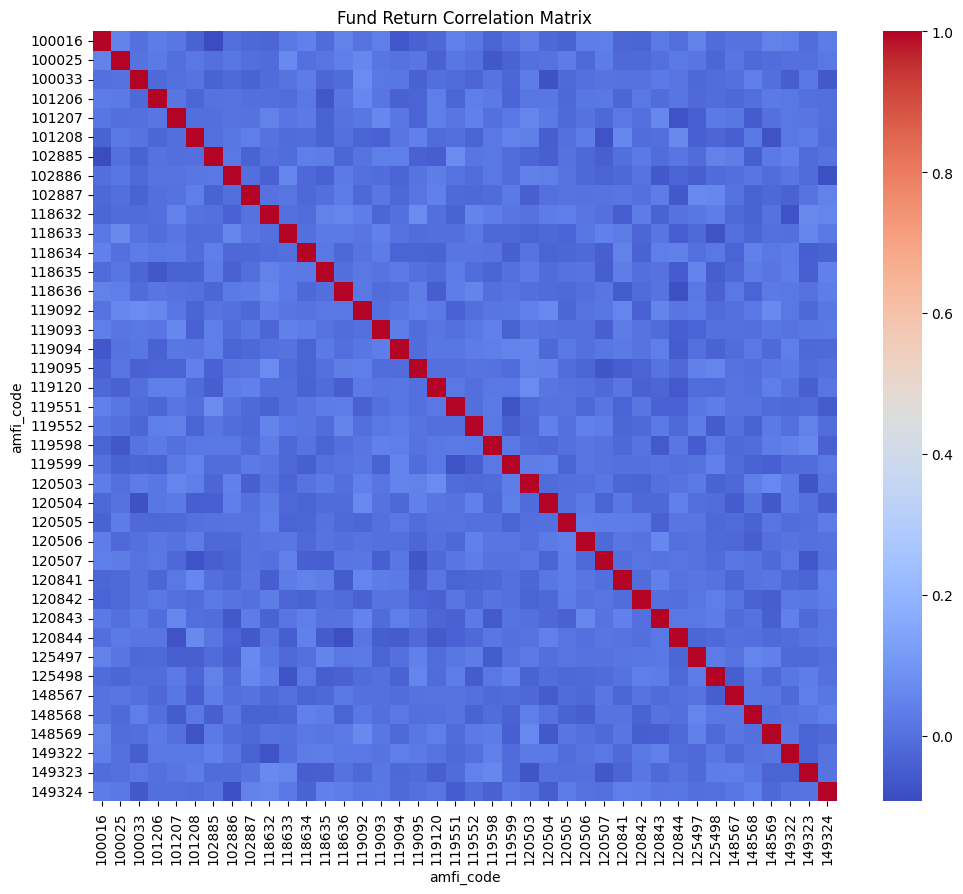

In [63]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Fund Return Correlation Matrix")

plt.savefig(
    "../reports/correlation_matrix.png",
    bbox_inches="tight"
)

plt.show()

# 9. Sector Allocation Analysis

In [64]:
sector = holdings.groupby(
    "sector"
)["weight_pct"].sum().sort_values(ascending=False)

print(sector.head())

sector
Banking       652.26
IT            455.47
Pharma        407.45
Automobile    323.65
Utilities     265.54
Name: weight_pct, dtype: float64


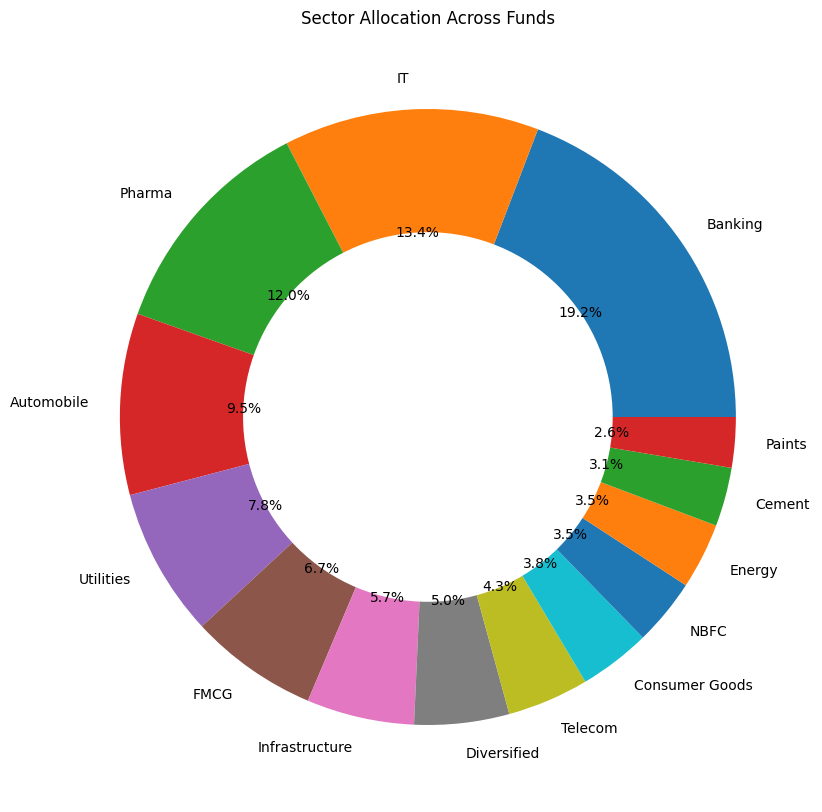

In [65]:
plt.figure(figsize=(10,10))

plt.pie(
    sector.values,
    labels=sector.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle(
    (0,0),
    0.60,
    fc="white"
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Funds")

plt.savefig(
    "../reports/sector_allocation.png",
    bbox_inches="tight"
)

plt.show()

# 10. Performance Analytics

In [66]:
top_sharpe = performance.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

top_sharpe[
    ["scheme_name","sharpe_ratio"]
]

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


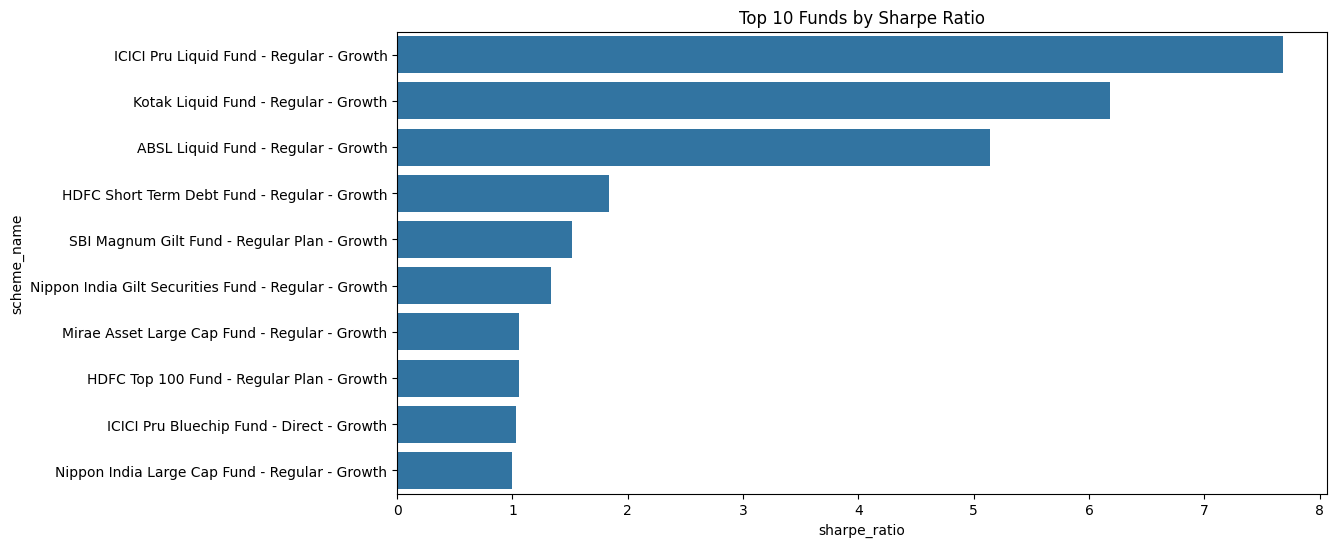

In [67]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.savefig(
    "../reports/top_sharpe_funds.png",
    bbox_inches="tight"
)

plt.show()

In [68]:
top_alpha = performance.sort_values(
    "alpha",
    ascending=False
).head(10)

top_alpha[
    ["scheme_name","alpha"]
]

,scheme_name,alpha
9,HDFC Short Term Debt Fund - Regular - Growth,1.98
21,Kotak Emerging Equity Fund - Regular - Growth,1.91
14,ICICI Pru Liquid Fund - Regular - Growth,1.85
22,Kotak Flexicap Fund - Regular - Growth,1.85
29,ABSL Small Cap Fund - Regular - Growth,1.84
37,DSP Top 100 Equity Fund - Regular - Growth,1.82
18,Nippon India ETF Nifty 50 BeES,1.80
33,UTI Flexi Cap Fund - Regular - Growth,1.79
1,SBI Bluechip Fund - Direct Plan - Growth,1.78
35,Mirae Asset Emerging Bluechip Fund - Regular -...,1.70


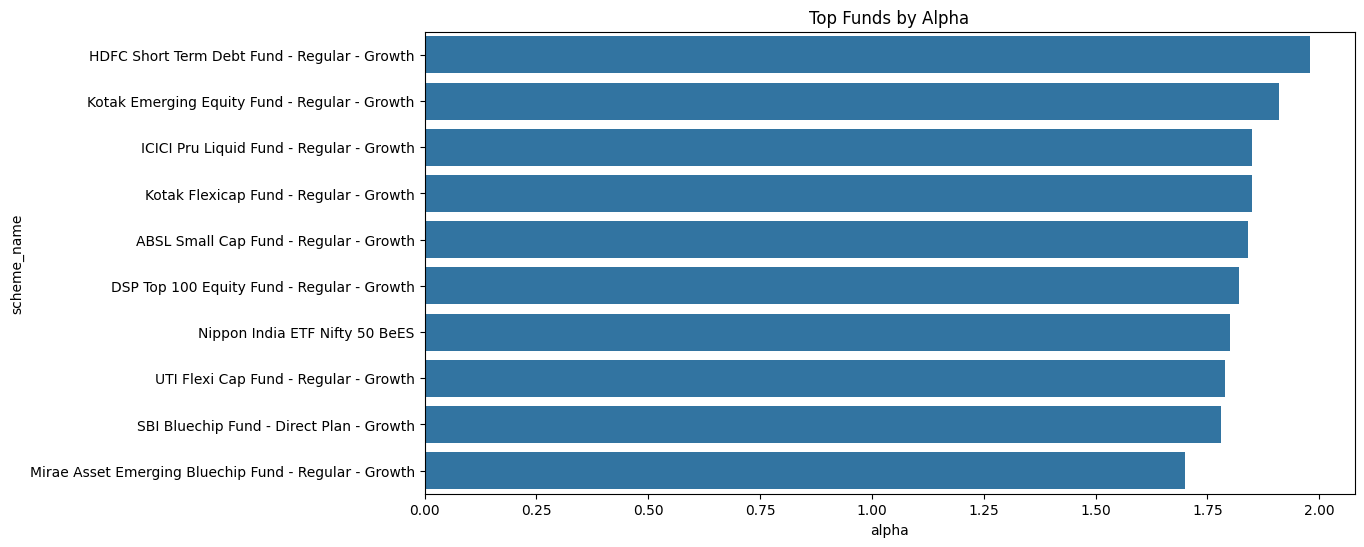

In [69]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_alpha,
    x="alpha",
    y="scheme_name"
)

plt.title("Top Funds by Alpha")

plt.savefig(
    "../reports/top_alpha_funds.png",
    bbox_inches="tight"
)

plt.show()

# Key EDA Findings

1. Mutual fund NAVs displayed an overall upward trend between 2022 and 2026.
2. Industry AUM increased steadily across major fund houses.
3. SIP inflows reached record highs during the study period.
4. Equity-oriented categories attracted the highest net inflows.
5. Folio counts showed strong growth, indicating increasing retail participation.
6. Investors in the middle-age groups contributed the largest share of investments.
7. T30 cities generated a significant portion of transaction volume.
8. State-wise investment distribution showed concentration in a few major states.
9. Most diversified equity funds exhibited positive return correlations.
10. Financial and technology sectors represented a large share of portfolio allocations.